## Part 1: Hypothesis Testing: Chi-Square Test (OverTime vs Attrition )

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

### 1.&nbsp; State the Null Hypothesis and the Alternative Hypothesis.

**Null Hypothesis ($H_0$):** Overtime and Attrition are independent.

**Alternative Hypothesis ($H_A$):** Overtime and attrition are associated.  

### 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

In [2]:
alpha = 0.5

### 3.&nbsp; Collect Data that is random and independent

Import the csv file and create a contingency table

In [5]:
df = pd.read_csv(r"C:\Users\babsn\Downloads\employees.csv", sep=";")

contingency_table = pd.crosstab(
    df['OverTime'],
    df['Attrition']
)

print(contingency_table)

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


In [4]:
df.shape

(1470, 16)

In [5]:
ct = pd.crosstab(
    df['OverTime'],
    df['Attrition']
)
ct['Total'] = ct.sum(axis=1)
ct['Attrition Rate (%)'] = round(ct['Yes'] / ct['Total'] * 100, 2)

print(ct)

Attrition   No  Yes  Total  Attrition Rate (%)
OverTime                                      
No         944  110   1054               10.44
Yes        289  127    416               30.53


In [6]:
print(df['OverTime'].unique())
print(df['Attrition'].unique())

<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Attrition Rates by Overtime Status

In [7]:
attrition_rates = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

print(attrition_rates.round(2))

Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


Calculate Attrition Rates by Overtime Status

In [9]:
attrition_rates = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

print(attrition_rates.round(2))

Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


Visualize It

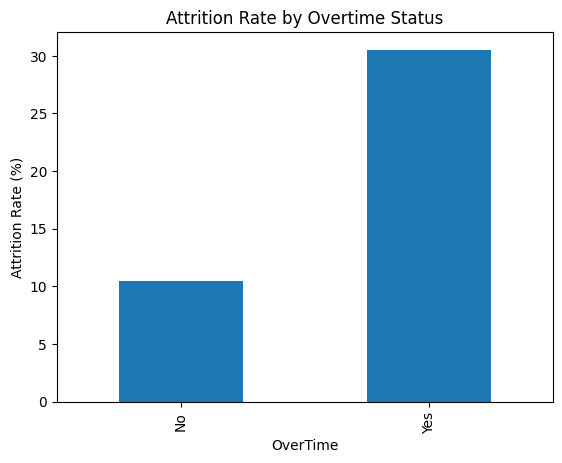

In [10]:
import matplotlib.pyplot as plt

attrition_rates['Yes'].plot(kind='bar')

plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Overtime Status')
plt.show()

### 4.&nbsp; Calculate the test result.

In [11]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 87.56429365828768
P-value: 8.158423721538322e-21


### 5.&nbsp; Interpret the test result.

In [12]:
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


## Final Insight
Employees who worked overtime experienced an attrition rate of 30.5%, compared to 10.4% among employees who did not work overtime. A chi-square test confirmed that the relationship between overtime and attrition is statistically significant, indicating that overtime is strongly associated with increased employee turnover.

## Part 2: Hypothesis Testing: T-Test (Monthly Income vs Attrition)

Do employees who leave earn significantly different salaries from employees who stay?

### 1.&nbsp; State the Null Hypothesis and the Alternative Hypothesis.

**Null Hypothesis ($H_0$):** Mean income is the same for employees who leave and stay..

**Alternative Hypothesis ($H_A$):** Mean income differs between the two groups.  

### 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

In [13]:
alpha = 0.02

### 3.&nbsp; Collect Data that is random and independent

Create the two groups

In [14]:
employees_left = df[df['Attrition'] == 'Yes']['MonthlyIncome']
employees_stayed = df[df['Attrition'] == 'No']['MonthlyIncome']

### 4.&nbsp; Calculate the test result.

In [15]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    employees_left,
    employees_stayed,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -7.482621586644742
P-value: 4.4335886282860673e-13


In [16]:
# Grouping the monthly income data
income_stayed = df[df['Attrition'] == 'No']['MonthlyIncome']
income_left = df[df['Attrition'] == 'Yes']['MonthlyIncome']

# Running a standard two-tailed independent t-test
t_stat, p_val = stats.ttest_ind(income_stayed, income_left, equal_var=False)

print(f"P-value: {p_val}")

# Decision rule
alpha = 0.02
if p_val < alpha:
    print("Reject the null hypothesis: Mean income differs significantly.")
else:
    print("Fail to reject the null hypothesis: No significant difference in mean income.")

P-value: 4.4335886282860673e-13
Reject the null hypothesis: Mean income differs significantly.


### 5.&nbsp; Interpret the test result.

In [17]:
if p < 0.02:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


In [18]:
if p > alpha:
  print("Do not reject the null hypothesis")
else:
  print("Reject the null hypothesis")

Reject the null hypothesis


## Final Insight
A t-test was conducted to compare monthly income between employees who left and those who stayed. The results showed a statistically significant difference (p < 0.02), indicating that compensation levels are associated with attrition. Employees who left the company tend to have lower average monthly income compared to those who remained.

Compensation appears to be a contributing factor to employee retention, suggesting that pay competitiveness may reduce turnover risk.